## Support Vector Classifier Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
## Lets create synthetic data points
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features= 2 , 
                           n_classes= 2 , n_clusters_per_class=2,
                           n_informative=2,n_redundant=0)

In [3]:
pd.DataFrame(X)[0]

0      0.848987
1      1.696766
2      1.393952
3     -0.917925
4      1.258318
         ...   
995   -2.516467
996    1.127757
997    1.268263
998    0.328609
999    2.014769
Name: 0, Length: 1000, dtype: float64

In [4]:
pd.DataFrame(X)[1]

0      0.131884
1      0.394940
2      0.545405
3      1.577672
4     -0.962615
         ...   
995   -0.899160
996   -0.503374
997   -0.896483
998   -3.992413
999    1.046111
Name: 1, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

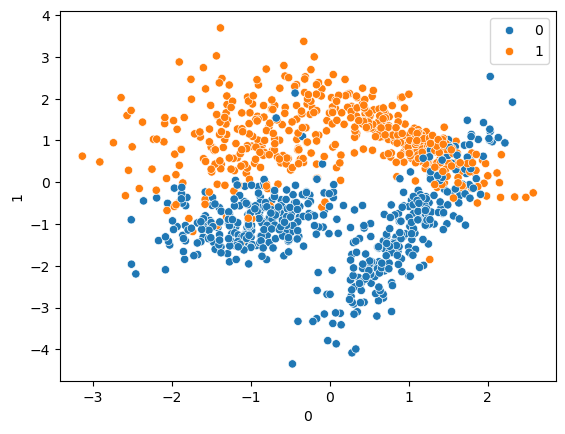

In [5]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
from sklearn.svm import SVC
svc = SVC(kernel ='linear')

In [8]:
svc.fit(X_train,y_train)
## Prediction
y_pred = svc.predict(X_test)

In [9]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

acc_score = accuracy_score(y_test, y_pred)

class_repo = classification_report(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)


print("Accuracy Score :", acc_score)

print("Classification Report:\n")
print(class_repo)

print("Confusion Matrix:\n")
print(conf_matrix)

Accuracy Score : 0.908
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       131
           1       0.90      0.91      0.90       119

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

Confusion Matrix:

[[119  12]
 [ 11 108]]


In [10]:
svc1= SVC(kernel='poly')
svc1.fit(X_train,y_train)
y_pred1 = svc1.predict(X_test)

acc_score = accuracy_score(y_test, y_pred1)

class_repo = classification_report(y_test, y_pred1)

conf_matrix = confusion_matrix(y_test, y_pred1)


print("Accuracy Score :", acc_score)

print("Classification Report:\n")
print(class_repo)

print("Confusion Matrix:\n")
print(conf_matrix)

Accuracy Score : 0.896
Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       131
           1       0.87      0.92      0.89       119

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

Confusion Matrix:

[[115  16]
 [ 10 109]]


In [11]:
svc2= SVC(kernel="rbf")
svc2.fit(X_train,y_train)
y_pred2 = svc2.predict(X_test)

acc_score = accuracy_score(y_test, y_pred2)

class_repo = classification_report(y_test, y_pred2)

conf_matrix = confusion_matrix(y_test, y_pred2)


print("Accuracy Score :", acc_score)

print("Classification Report:\n")
print(class_repo)

print("Confusion Matrix:\n")
print(conf_matrix)

Accuracy Score : 0.9
Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.84      0.90       131
           1       0.85      0.97      0.90       119

    accuracy                           0.90       250
   macro avg       0.91      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

Confusion Matrix:

[[110  21]
 [  4 115]]


In [12]:
svc3= SVC(kernel="sigmoid")
svc3.fit(X_train,y_train)
y_pred3 = svc3.predict(X_test)

acc_score = accuracy_score(y_test, y_pred3)

class_repo = classification_report(y_test, y_pred3)

conf_matrix = confusion_matrix(y_test, y_pred3)


print("Accuracy Score :", acc_score)

print("Classification Report:\n")
print(class_repo)

print("Confusion Matrix:\n")
print(conf_matrix)

Accuracy Score : 0.872
Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       131
           1       0.86      0.87      0.87       119

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250

Confusion Matrix:

[[114  17]
 [ 15 104]]


## Hyperparametere Tuning With SVC

In [13]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [1000, 100, 10, 1, 0.1, 0.01]
    },

    {
        'kernel': ['rbf'],
        'C': [1000, 100, 10, 1, 0.1, 0.01],
        'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
    },

    {
        'kernel': ['poly'],
        'C': [1000, 100, 10, 1, 0.1],
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto', 0.1, 0.01]
    },

    {
        'kernel': ['sigmoid'],
        'C': [1000, 100, 10, 1, 0.1],
        'gamma': ['scale', 'auto', 0.1, 0.01]
    }
]

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC()

grid = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 142 candidates, totalling 710 fits
[CV 3/5] END ..............C=100, kernel=linear;, score=0.867 total time=   0.0s
[CV 3/5] END .............C=1000, kernel=linear;, score=0.867 total time=   0.1s
[CV 1/5] END ..............C=100, kernel=linear;, score=0.940 total time=   0.0s
[CV 5/5] END ..............C=100, kernel=linear;, score=0.860 total time=   0.0s
[CV 5/5] END .............C=1000, kernel=linear;, score=0.860 total time=   0.1s
[CV 2/5] END .............C=1000, kernel=linear;, score=0.933 total time=   0.1s
[CV 4/5] END .............C=1000, kernel=linear;, score=0.853 total time=   0.1s
[CV 4/5] END ..............C=100, kernel=linear;, score=0.853 total time=   0.0s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.940 total time=   0.0s
[CV 2/5] END ...............C=10, kernel=linear;, score=0.933 total time=   0.0s
[CV 3/5] END ...............C=10, kernel=linear;, score=0.867 total time=   0.0s
[CV 5/5] END ...............C=10, kernel=linea

In [16]:
y_pred4 = grid.predict(X_test)

acc_score = accuracy_score(y_test, y_pred4)

class_repo = classification_report(y_test, y_pred4)

conf_matrix = confusion_matrix(y_test, y_pred4)

print("Accuracy Score :", acc_score)

print("Classification Report:\n")
print(class_repo)

print("Confusion Matrix:\n")
print(conf_matrix)

Accuracy Score : 0.908
Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.86      0.91       131
           1       0.86      0.96      0.91       119

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

Confusion Matrix:

[[113  18]
 [  5 114]]
